In [1]:
from src.objetos import Dados, camada_densa, rede_neural
import numpy as np
from matplotlib import pyplot as plt

In [2]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

In [3]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

In [4]:
dados._holdout(0.6, 0.2)

In [5]:
epocas = 500
taxa_aprendizado = 2
lambda_reg = 1
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]

In [6]:
camadas = []

for i in range(len(arquitetura_camadas)-2):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='sigmoid'
        )
    camadas.append(camada)
# Aplica softmax na ultima camada
camada_soft = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[-2], 
        tamanho_saida=arquitetura_camadas[-1],
        funcao_de_ativacao='softmax'
)
camadas.append(camada_soft)

print(camadas)


[<src.objetos.camada_densa.CamadaDensa object at 0x7a79bca0dd30>, <src.objetos.camada_densa.CamadaDensa object at 0x7a7a0d6a8190>]


In [7]:
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

In [8]:
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg
)

In [9]:
theta = np.delete(rede.camadas[0].parametros[-1], 0)
theta = (theta - np.min(theta))/(np.max(theta) - np.min(theta))
img = theta.reshape((20,20))


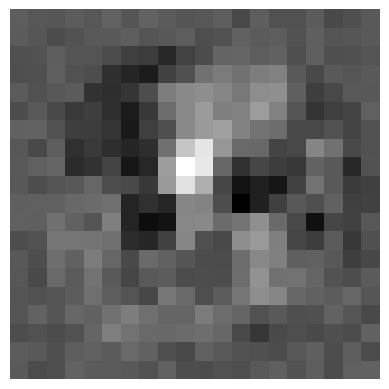

In [10]:
plt.figure()
plt.imshow(img, cmap='binary', vmin=0, vmax=1)
plt.axis('off')
plt.show()

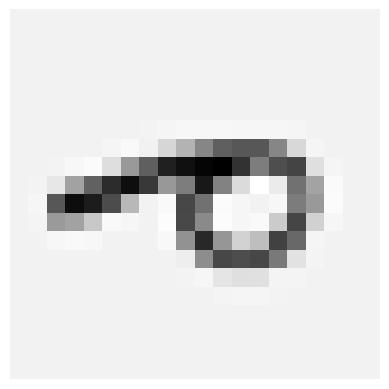

In [11]:
vetor = dados.conjunto_treinamento[0].T[116]

vetor = (vetor - np.min(vetor))/(np.max(vetor) - np.min(vetor))
img_vetor = vetor.reshape((20,20))
plt.figure()
plt.imshow(img_vetor, cmap='binary', vmin=0, vmax=1)
plt.axis('off')
plt.show()